 ## Airbnb tra Roma e Berlino

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("airbnb_european-cities.csv")

cities = ["Rome", "Berlin"]
d = df[df["city"].str.contains("|".join(cities), case=False, na=False)].copy()

# pulizia minima
d = d.dropna(subset=["realSum","room_type"])
d = d[d["realSum"] > 0]
q99 = d["realSum"].quantile(0.99)   # taglia outlier estremi
d = d[d["realSum"] <= q99]


**Prezzo mediano per tipo stanza**

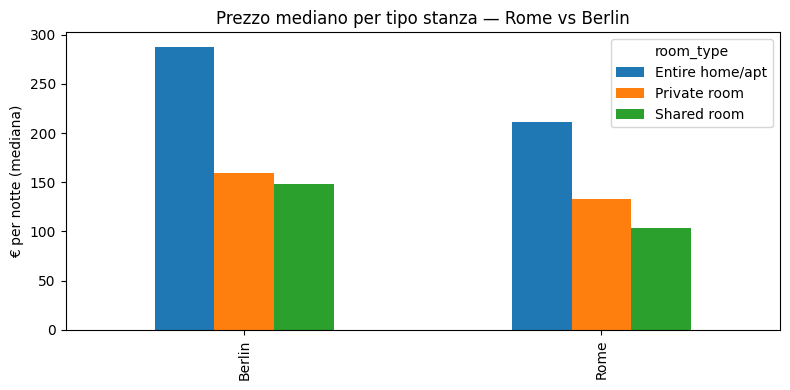

In [4]:
med = d.groupby(["city","room_type"])["realSum"].median().unstack()
ax = med.plot(kind="bar", figsize=(8,4))
ax.set_title("Prezzo mediano per tipo stanza — Rome vs Berlin")
ax.set_ylabel("€ per notte (mediana)")
ax.set_xlabel("")
ax.legend(title="room_type")
plt.tight_layout(); plt.show()


**Correlazione pulizia vs soddisfazione**

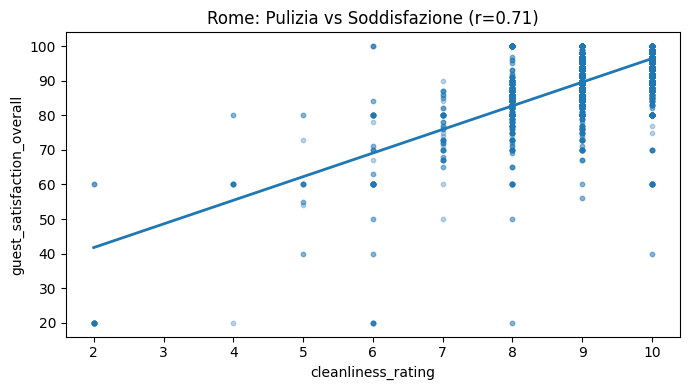

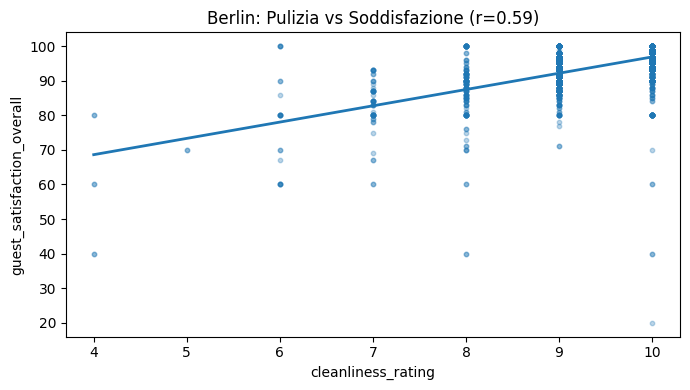

In [5]:
for c in cities:
    sub = d[d["city"].str.contains(c, case=False, na=False)].dropna(
        subset=["cleanliness_rating","guest_satisfaction_overall"])
    x = sub["cleanliness_rating"].to_numpy()
    y = sub["guest_satisfaction_overall"].to_numpy()

    plt.figure(figsize=(7,4))
    plt.scatter(x, y, s=10, alpha=0.3)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    plt.plot(xs, m*xs + b, linewidth=2)
    r = np.corrcoef(x, y)[0,1]
    plt.title(f"{c}: Pulizia vs Soddisfazione (r={r:.2f})")
    plt.xlabel("cleanliness_rating"); plt.ylabel("guest_satisfaction_overall")
    plt.tight_layout(); plt.show()


**Prezzo vs distanza dal centro**

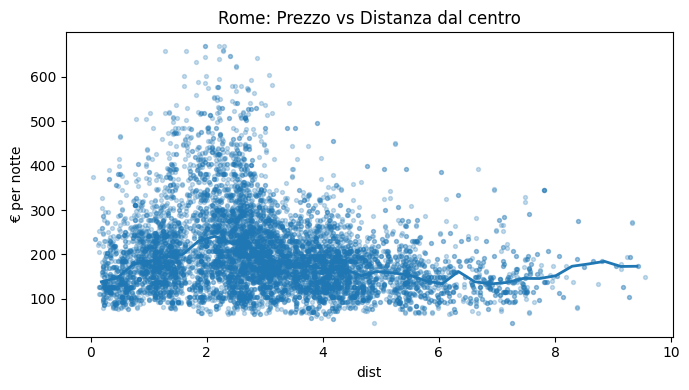

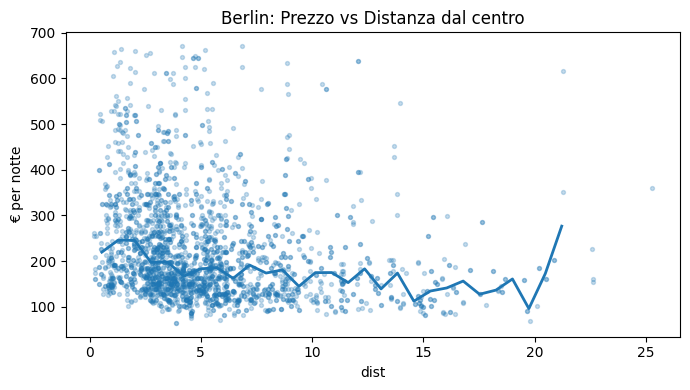

In [8]:
for c in cities:
    sub = d[d["city"].str.contains(c, case=False, na=False)].dropna(subset=["dist","realSum"])

    plt.figure(figsize=(7,4))
    plt.scatter(sub["dist"], sub["realSum"], s=8, alpha=0.25)

    # binning
    bins = np.linspace(sub["dist"].min(), sub["dist"].max(), 35)
    gb = pd.cut(sub["dist"], bins, include_lowest=True)

    # mediana per bin (forza observed=False per includere anche i bin vuoti)
    med = sub.groupby(gb, observed=False)["realSum"].median()

    cats = gb.cat.categories           # IntervalIndex
    mids = cats.mid                    # <-- qui funziona
    y = med.reindex(cats).values       # allinea ai bin (anche se alcuni sono NaN)

    plt.plot(mids, y, linewidth=2)
    plt.title(f"{c}: Prezzo vs Distanza dal centro")
    plt.xlabel("dist"); plt.ylabel("€ per notte")
    plt.tight_layout(); plt.show()


**Il Superhost è più caro?**

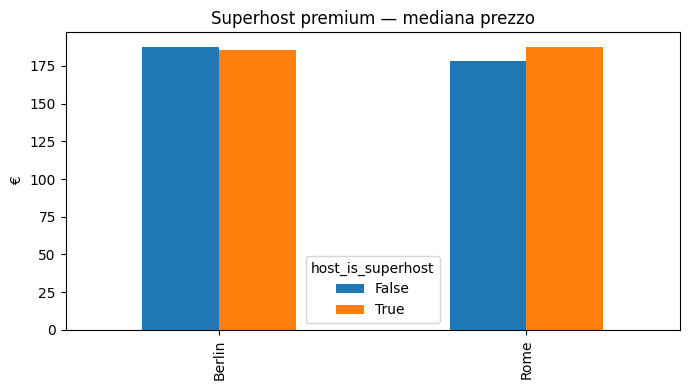

Premium % Superhost:
city
Berlin    -1.2%
Rome       5.1%
dtype: object


In [7]:
prem = d.groupby(["city","host_is_superhost"])["realSum"].median().unstack()
ax = prem.plot(kind="bar", figsize=(7,4))
ax.set_title("Superhost premium — mediana prezzo"); ax.set_ylabel("€"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

# differenza percentuale (solo a console)
premium = (prem[True] - prem[False]) / prem[False] * 100
print("Premium % Superhost:")
print(premium.round(1).astype(str) + "%")
